# Frequency Domain

This notebook contains the runnable Python examples from the [Frequency Domain chapter](https://pysdr.org/content/frequency_domain.html) of PySDR.

It covers:

1. Computing an FFT with NumPy and plotting the magnitude and phase
2. Applying a window function before the FFT
3. Building a spectrogram (waterfall)
4. A from-scratch recursive FFT implementation


## FFT in Python

First we create a signal in the time domain. To keep things simple, we make a sine wave at 0.15 Hz,
using a sample rate of 1 Hz (so we sample at t = 0, 1, 2, 3 seconds, etc.).

We then take the FFT, apply an `fftshift` so that 0 Hz (DC) is in the center with negative
frequencies to the left, and plot the magnitude and phase with a proper frequency x-axis.
Because our sample rate is 1 Hz, the x-axis spans -0.5 Hz to 0.5 Hz.


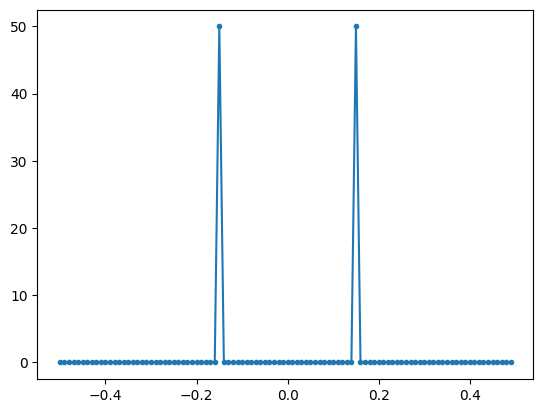

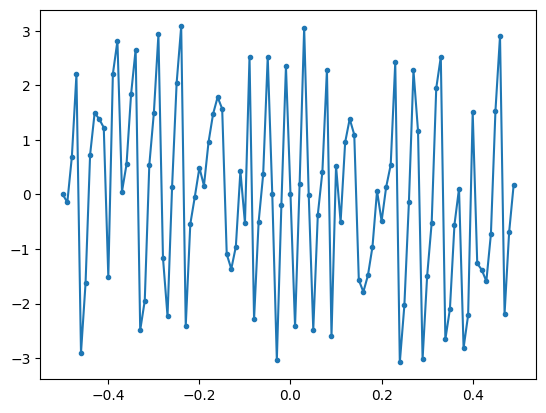

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 1 # Hz
N = 100 # number of points to simulate, and our FFT size

t = np.arange(N) # because our sample rate is 1 Hz
s = np.sin(0.15*2*np.pi*t)
S = np.fft.fftshift(np.fft.fft(s))
S_mag = np.abs(S)
S_phase = np.angle(S)
f = np.arange(Fs/-2, Fs/2, Fs/N)
plt.figure(0)
plt.plot(f, S_mag,'.-')
plt.figure(1)
plt.plot(f, S_phase,'.-')
plt.show()

We see our spike at 0.15 Hz, which is the frequency we used when creating the sine wave, so the FFT
worked! The reason we also see a spike at -0.15 Hz is because it was a real signal (not complex).

## Windowing

When we use an FFT, it assumes the slice of signal we give it is one period of a periodic signal, so
we want to avoid sudden transitions between the first and last sample. We fix this by "windowing":
multiplying the slice by a function that tapers to zero on both ends, such as a Hamming window.

Here we apply a Hamming window to the same sine wave before taking the FFT.

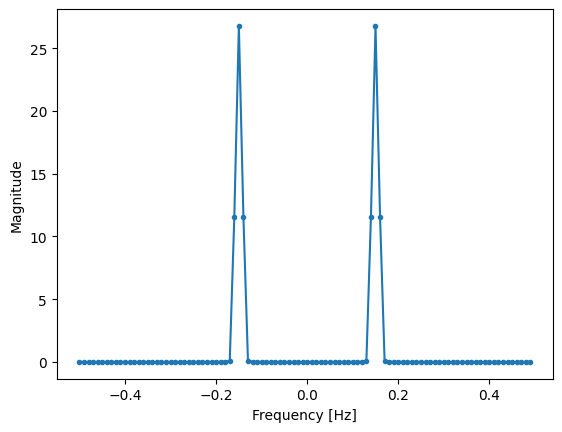

In [2]:
Fs = 1 # Hz
N = 100 # number of points to simulate, and our FFT size

t = np.arange(N)
s = np.sin(0.15*2*np.pi*t)
s = s * np.hamming(N) # apply the window right before the FFT
S = np.fft.fftshift(np.fft.fft(s))
S_mag = np.abs(S)
f = np.arange(Fs/-2, Fs/2, Fs/N)
plt.plot(f, S_mag,'.-')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.show()

## Spectrogram / Waterfall

A spectrogram is simply a bunch of FFTs stacked together, showing frequency over time. Let's create
an example signal that is a tone at 50 kHz in white noise, sampled at 1 MHz.

In [3]:
sample_rate = 1e6

# Generate tone plus noise
t = np.arange(1024*1000)/sample_rate # time vector
f = 50e3 # freq of tone
x = np.sin(2*np.pi*f*t) + 0.2*np.random.randn(len(t))

Here is what the signal looks like in the time domain (first 200 samples):

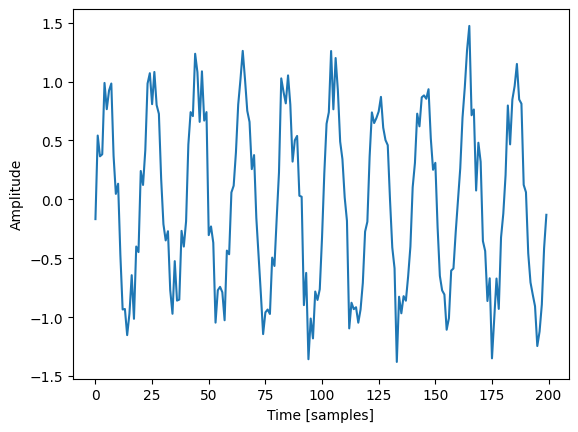

In [4]:
plt.plot(x[0:200])
plt.xlabel("Time [samples]")
plt.ylabel("Amplitude")
plt.show()

Now we slice the signal into chunks of our FFT size, take the FFT of each, convert to dB, and stack
them into a 2D array that we display with `imshow`. Time starts at the top and goes down.

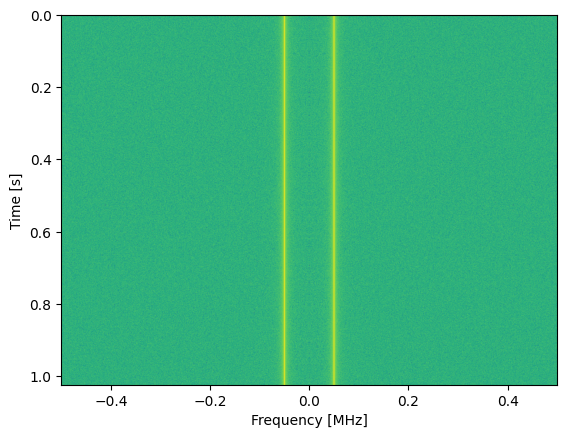

In [5]:
fft_size = 1024
num_rows = len(x) // fft_size # // is an integer division which rounds down
spectrogram = np.zeros((num_rows, fft_size))
for i in range(num_rows):
    spectrogram[i,:] = 10*np.log10(np.abs(np.fft.fftshift(np.fft.fft(x[i*fft_size:(i+1)*fft_size])))**2)

# Time starts at the top and goes down, eg sample x[0] will be part of the top row displayed
plt.imshow(spectrogram, aspect='auto', extent = (sample_rate/-2/1e6, sample_rate/2/1e6, len(x)/sample_rate, 0))
plt.xlabel("Frequency [MHz]")
plt.ylabel("Time [s]")
plt.show()

There are two tones because we simulated a real signal, and real signals always have a negative side
of the spectrum that mirrors the positive side.

## FFT Implementation

Even though NumPy already implements the FFT for us, it's nice to see how it works under the hood.
Below is a simple recursive implementation of the Cooley-Tukey FFT, along with an example signal
consisting of a complex tone plus noise (0 dB SNR).

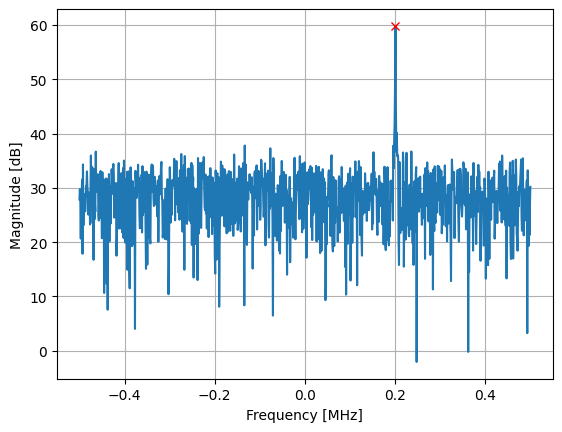

In [6]:
def fft(x):
    N = len(x)
    if N == 1:
        return x
    twiddle_factors = np.exp(-2j * np.pi * np.arange(N//2) / N)
    x_even = fft(x[::2]) # yay recursion!
    x_odd = fft(x[1::2])
    return np.concatenate([x_even + twiddle_factors * x_odd,
                           x_even - twiddle_factors * x_odd])

# Simulate a tone + noise
sample_rate = 1e6
f_offset = 0.2e6 # 200 kHz offset from carrier
N = 1024
t = np.arange(N)/sample_rate
s = np.exp(2j*np.pi*f_offset*t)
n = (np.random.randn(N) + 1j*np.random.randn(N))/np.sqrt(2) # unity complex noise
r = s + n # 0 dB SNR

# Perform fft, fftshift, convert to dB
X = fft(r)
X_shifted = np.roll(X, N//2) # equivalent to np.fft.fftshift
X_mag = 10*np.log10(np.abs(X_shifted)**2)

# Plot results
f = np.linspace(sample_rate/-2, sample_rate/2, N)/1e6 # plt in MHz
plt.plot(f, X_mag)
plt.plot(f[np.argmax(X_mag)], np.max(X_mag), 'rx') # show max
plt.grid()
plt.xlabel('Frequency [MHz]')
plt.ylabel('Magnitude [dB]')
plt.show()